# Compute a transfer function

Atmospheric emission can dominate the noise budget and must be removed from the time-ordered data before mapping. This filtering inevitably projects out correlated sky modes, suppressing signal at large angular scales. The spatial transfer function $T(u)$ provides a direct estimate of this scale-dependent signal loss. `maria` includes a built-in function to compute this, using the cross-spectrum between the output and the known input map:

$$T(u) = \frac{\mathrm{Re}\langle \tilde{s}_{\rm in}^*(u)\,\tilde{s}_{\rm out}(u)\rangle}{\langle|\tilde{s}_{\rm in}(u)|^2\rangle}$$

Please note that the cross-spectrum is used instead of the power ratio $P_{\rm out}/P_{\rm in}$ because noise in the output is uncorrelated with the input and averages to zero, leaving an unbiased estimate.

## Input sky

In this tutorial, we simulate a two-frequency observation of a galaxy cluster at 150 and 270 GHz and recover a map with the `BinMapper`. We load the same map at both frequencies — any difference in the recovered signal will come from the instrument and the filtering alone.

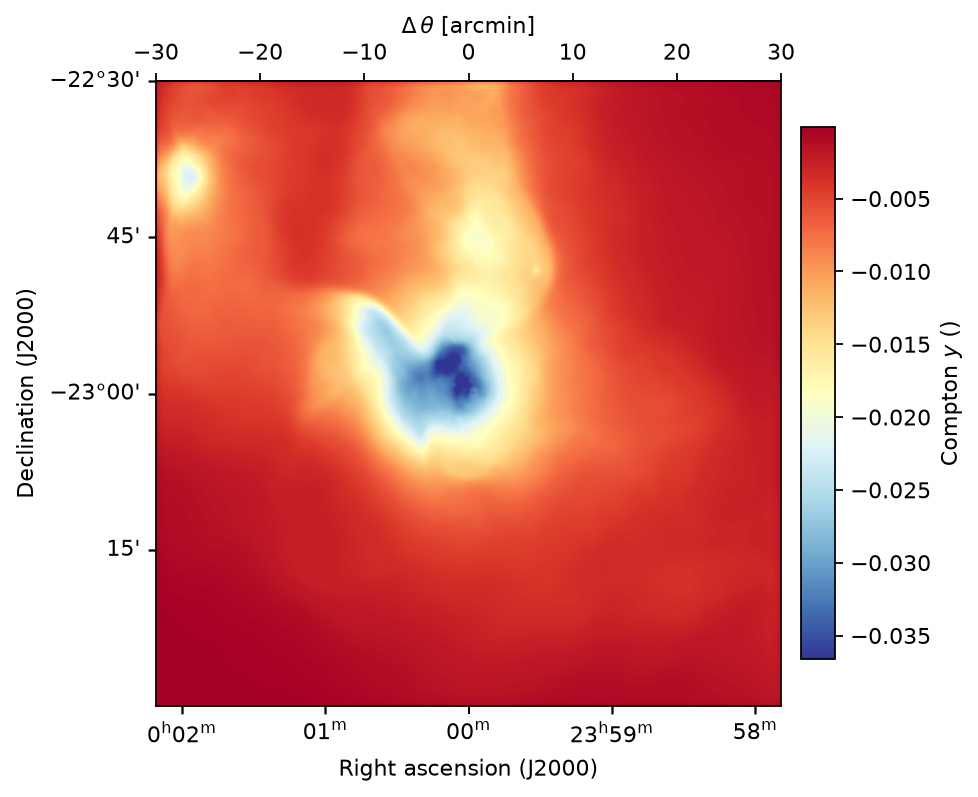

In [1]:
import maria
import matplotlib.pyplot as plt
import numpy as np
from maria.io import fetch

map_filename = fetch("maps/cluster2.fits")

input_map = maria.map.load(filename=map_filename, center=(0, -23))
input_map.data *= 1e4
input_map.plot(slices="all", cmap="RdYlBu_r")

## Instrument and observation plan

We use TolTEC on the LMT, keeping only the 150 and 270 GHz arrays and dropping the 220 GHz one for efficiency. Because the beam is diffraction-limited, the 270 GHz array resolves angular scales roughly 1.8× finer than the 150 GHz array.

Instrument(1 array)
├ arrays:
│            n field_of_view max_baseline        bands polarized primary_size
│  array1  244        15.13’          0 m  [f150,f270]     False         12 m
│ 
└ bands:
      name   center   width    η         NEP       NET_RJ         NET_CMB    FWHM
   0  f150  150 GHz  20 GHz  0.5  14.69 aW√s  100 uK_RJ√s  173.4 uK_CMB√s  43.74”
   1  f270  270 GHz  40 GHz  0.5  29.38 aW√s  100 uK_RJ√s  498.5 uK_CMB√s   24.3”


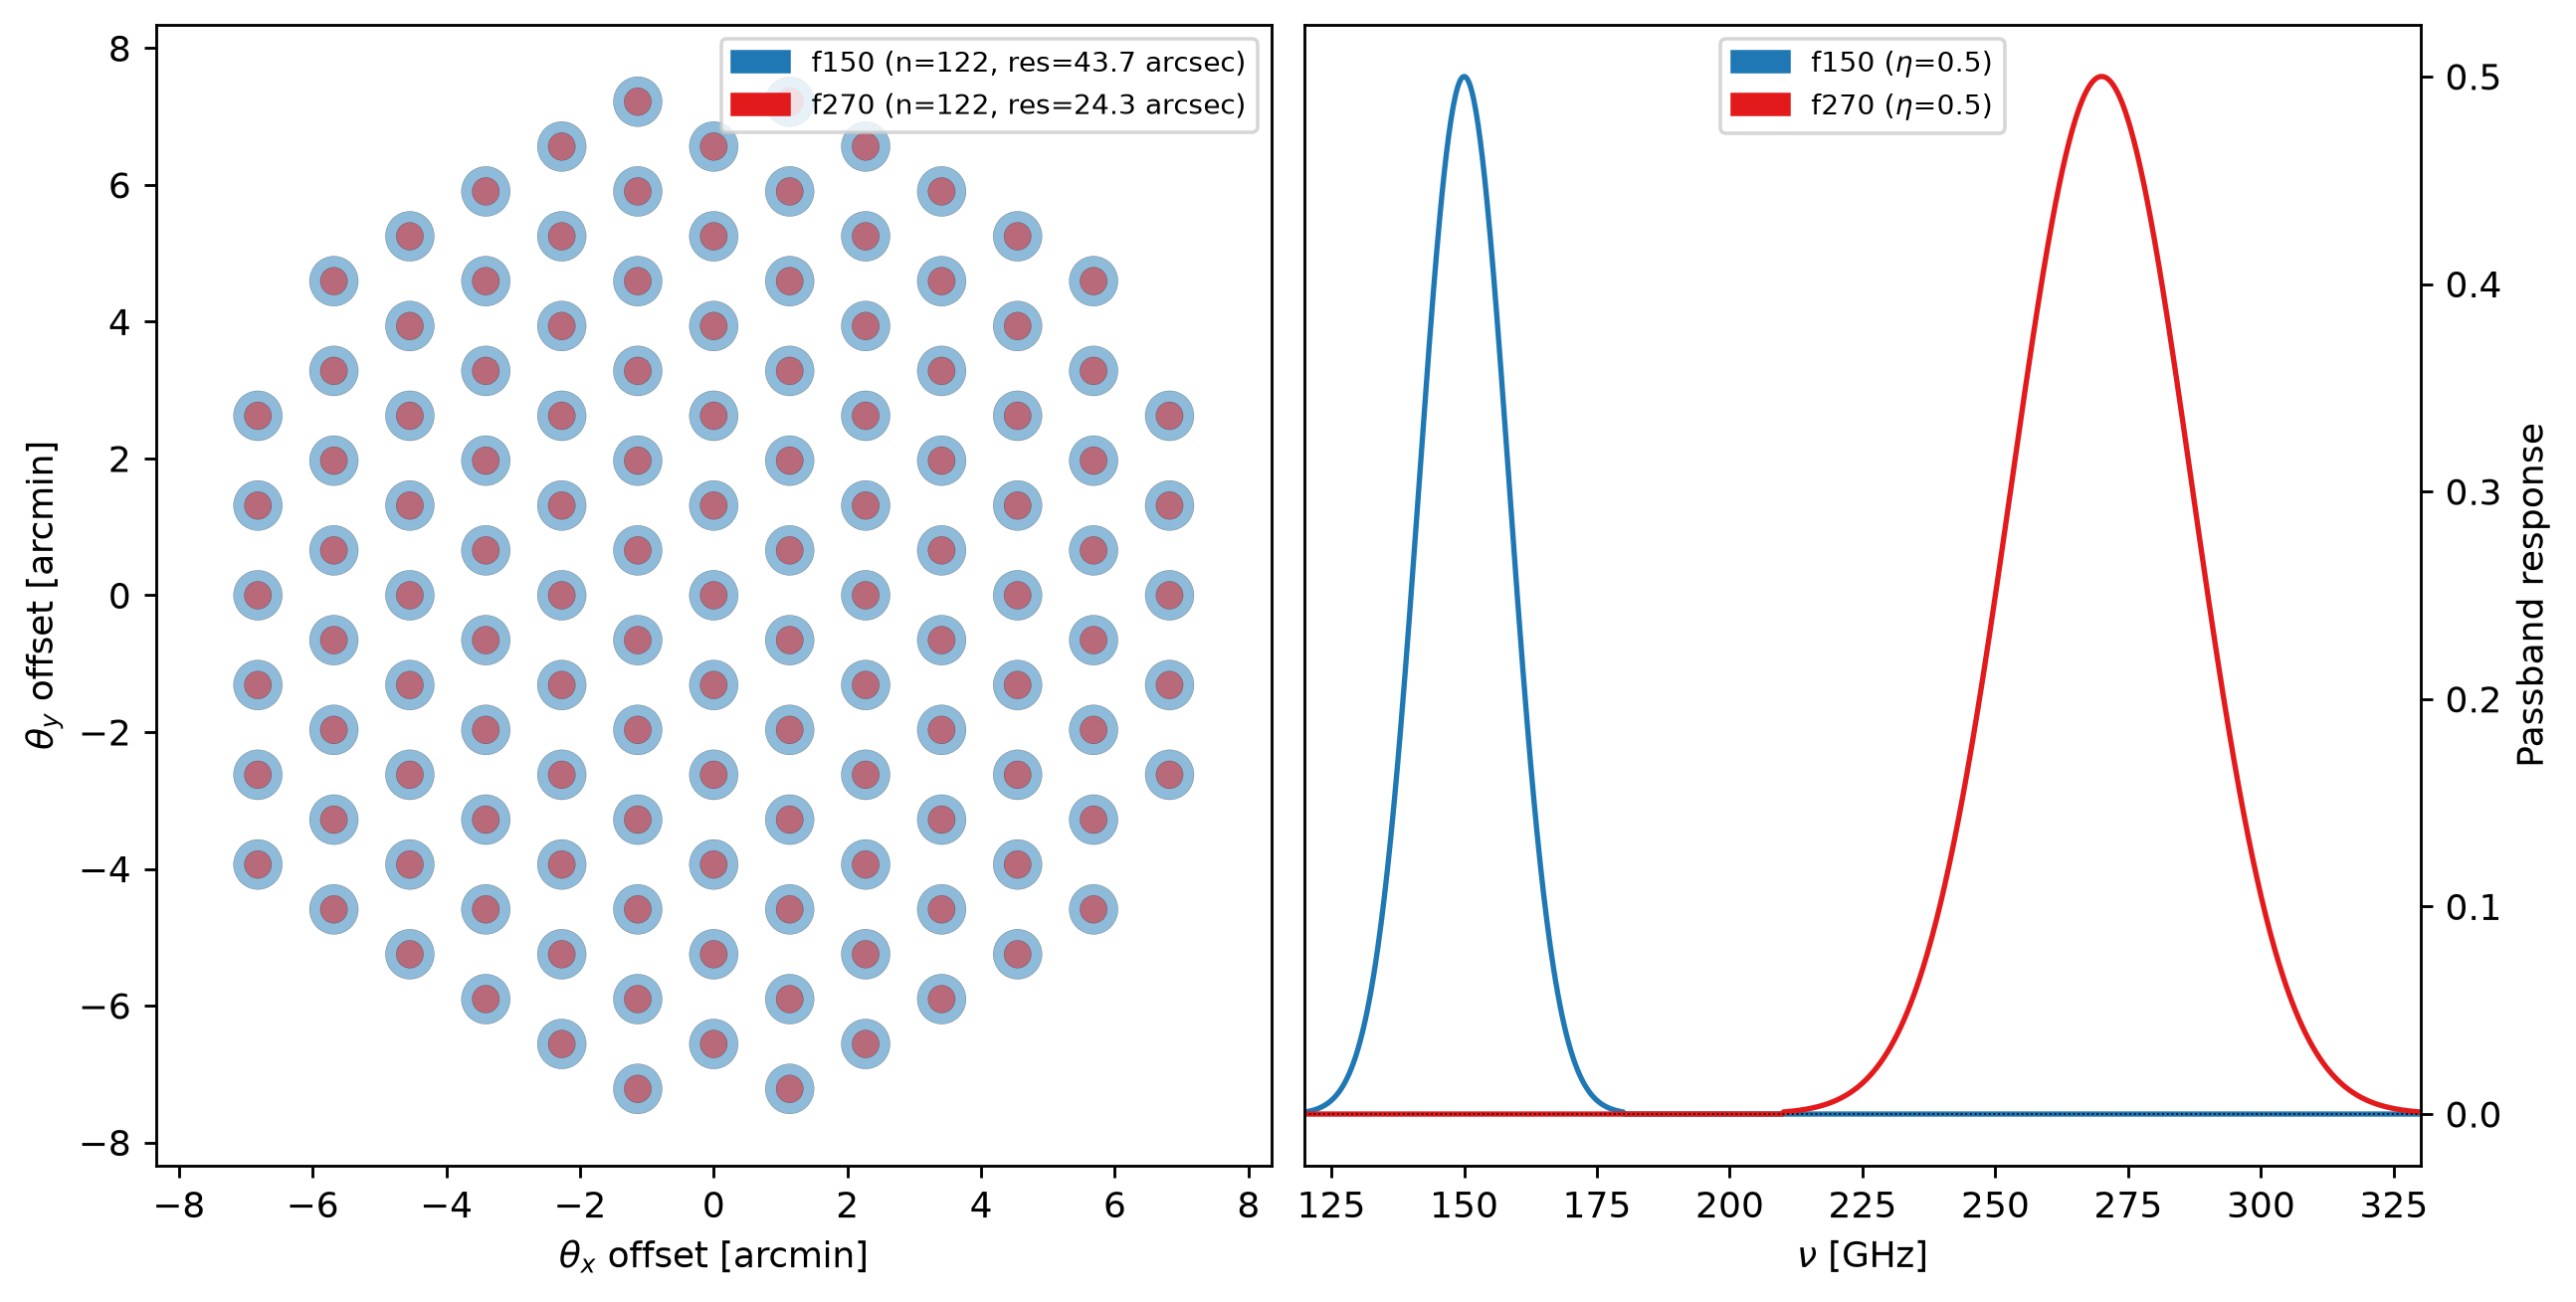

In [2]:
import maria
from maria.instrument import Band

f090 = Band(center=150e9, width=20e9, NET_RJ=100e-6)
f150 = Band(center=270e9, width=40e9, NET_RJ=100e-6)

array = {"field_of_view": 0.25, 
         "beam_spacing": 1.8,
         "primary_size": 12, 
         "shape": "circle",
         "bands": [f090, f150]}

instrument = maria.get_instrument(array=array)

print(instrument)
instrument.plot()

PlanList(1 plans, 1800 s):
                           start_time duration sample_rate         target(ra,dec)     center(az,el)
chunk                                                                                              
0      2024-01-02 19:35:37.500 +00:00   1800 s       50 Hz  (126.6 marcsec, -23°)  (95.33°, 63.84°)

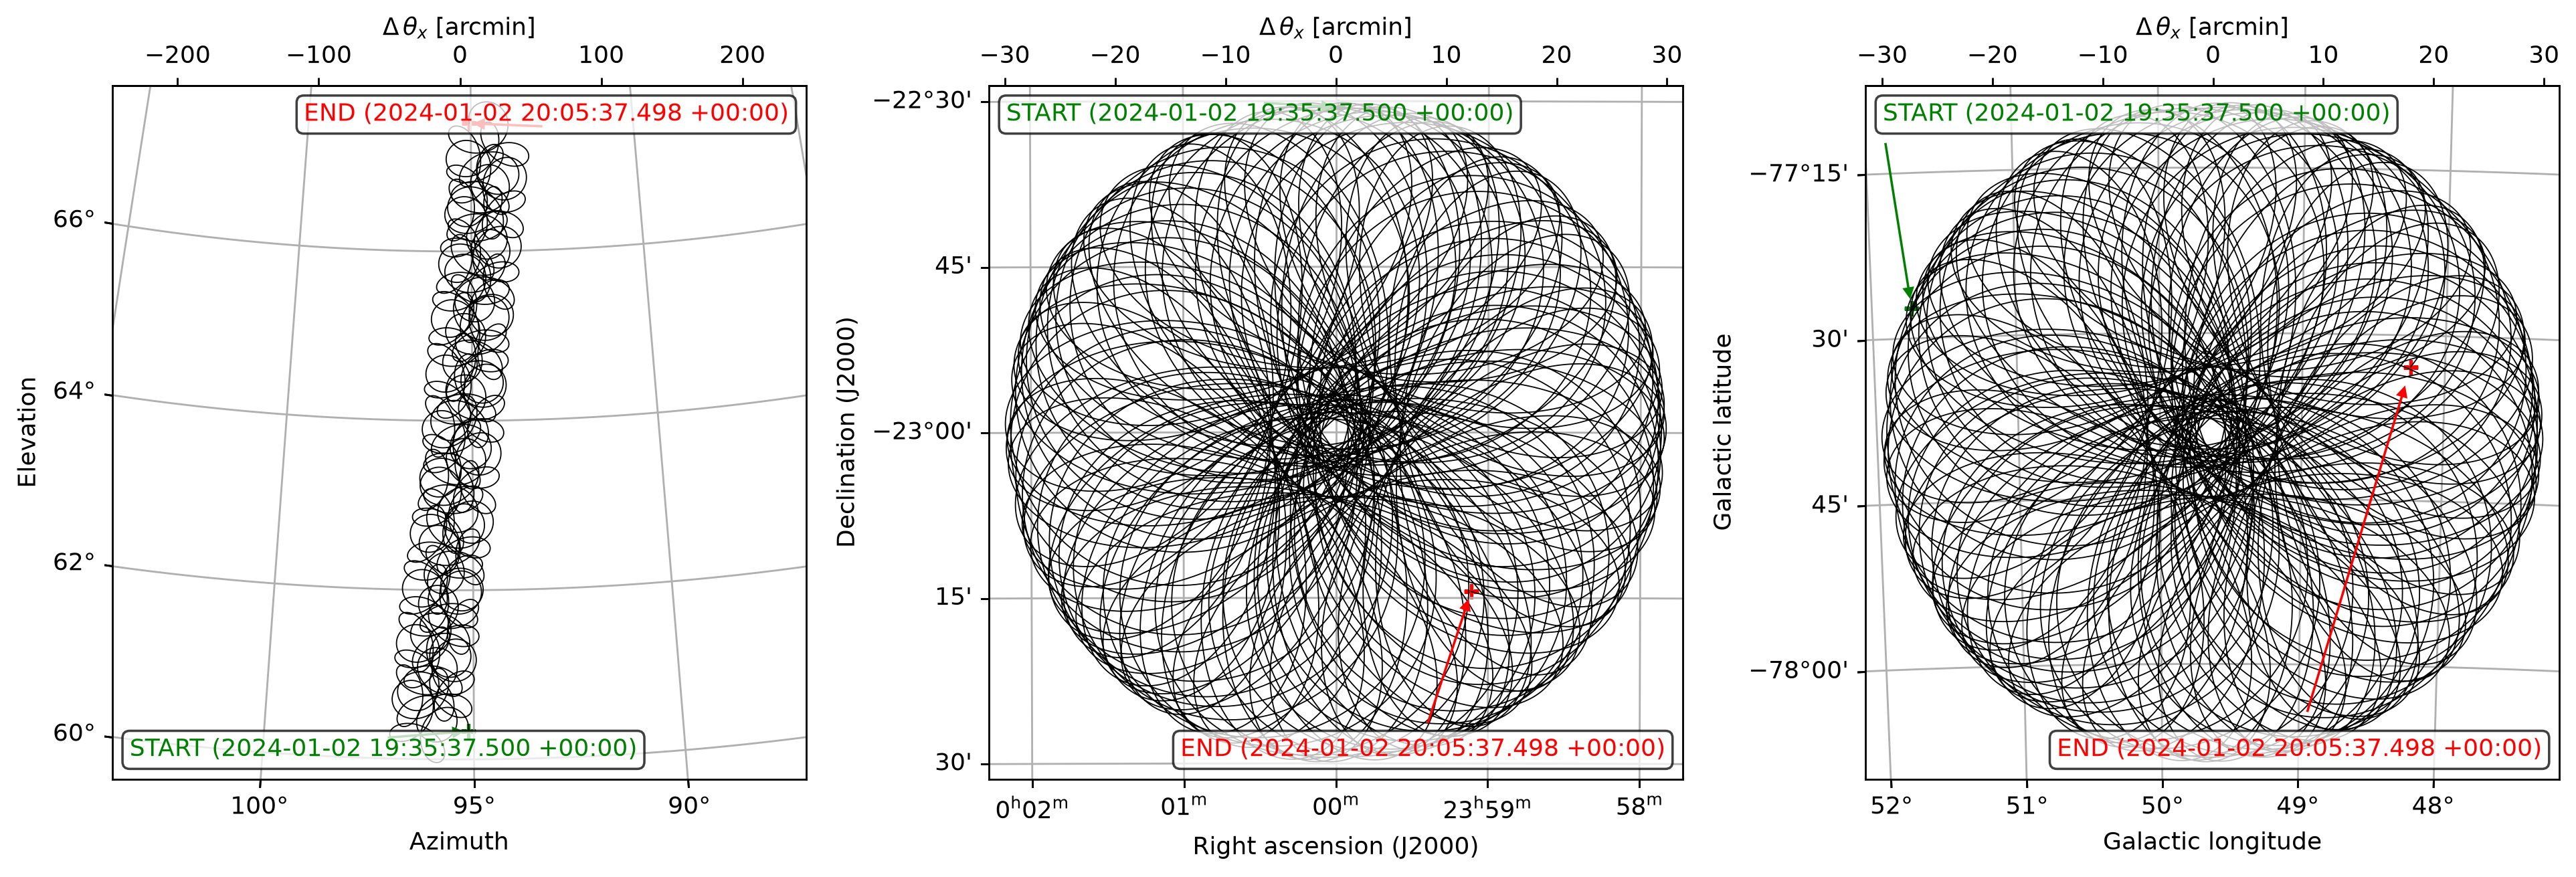

In [3]:
from maria import Planner

planner = Planner(
    target=input_map,
    start_time="2024-01-01T22:00:00",
    site="llano_de_chajnantor",
    constraints={"el": (60, 90)},
)

plans = planner.generate_plans(
    total_duration=1800,
    sample_rate=50,
    scan_type="daisy",
)

plans[0].plot()
plans

## Simulation

Passing `map=input_map` attaches the ground-truth sky to each output TOD so the mapper can propagate it to the output map automatically.

Initializing observations:   0%|          | 0/1 [00:00<?, ?it/s]

Constructing atmosphere:   0%|          | 0/8 [00:00<?, ?it/s]

Constructing atmosphere:  12%|█▎        | 1/8 [00:05<00:36,  5.25s/it]

Constructing atmosphere:  25%|██▌       | 2/8 [00:10<00:31,  5.18s/it]

Constructing atmosphere:  38%|███▊      | 3/8 [00:16<00:28,  5.64s/it]

...

Generating noise:  50%|█████     | 1/2 [00:01<00:01,  1.29s/it, band=f150]

Generating noise:  50%|█████     | 1/2 [00:01<00:01,  1.29s/it, band=f270]

Generating noise: 100%|██████████| 2/2 [00:02<00:00,  1.00s/it, band=f270]

Generating noise: 100%|██████████| 2/2 [00:02<00:00,  1.05s/it, band=f270]

2026-07-06 18:04:25.055 INFO: Simulated observation 1 of 1 in 33.28 s


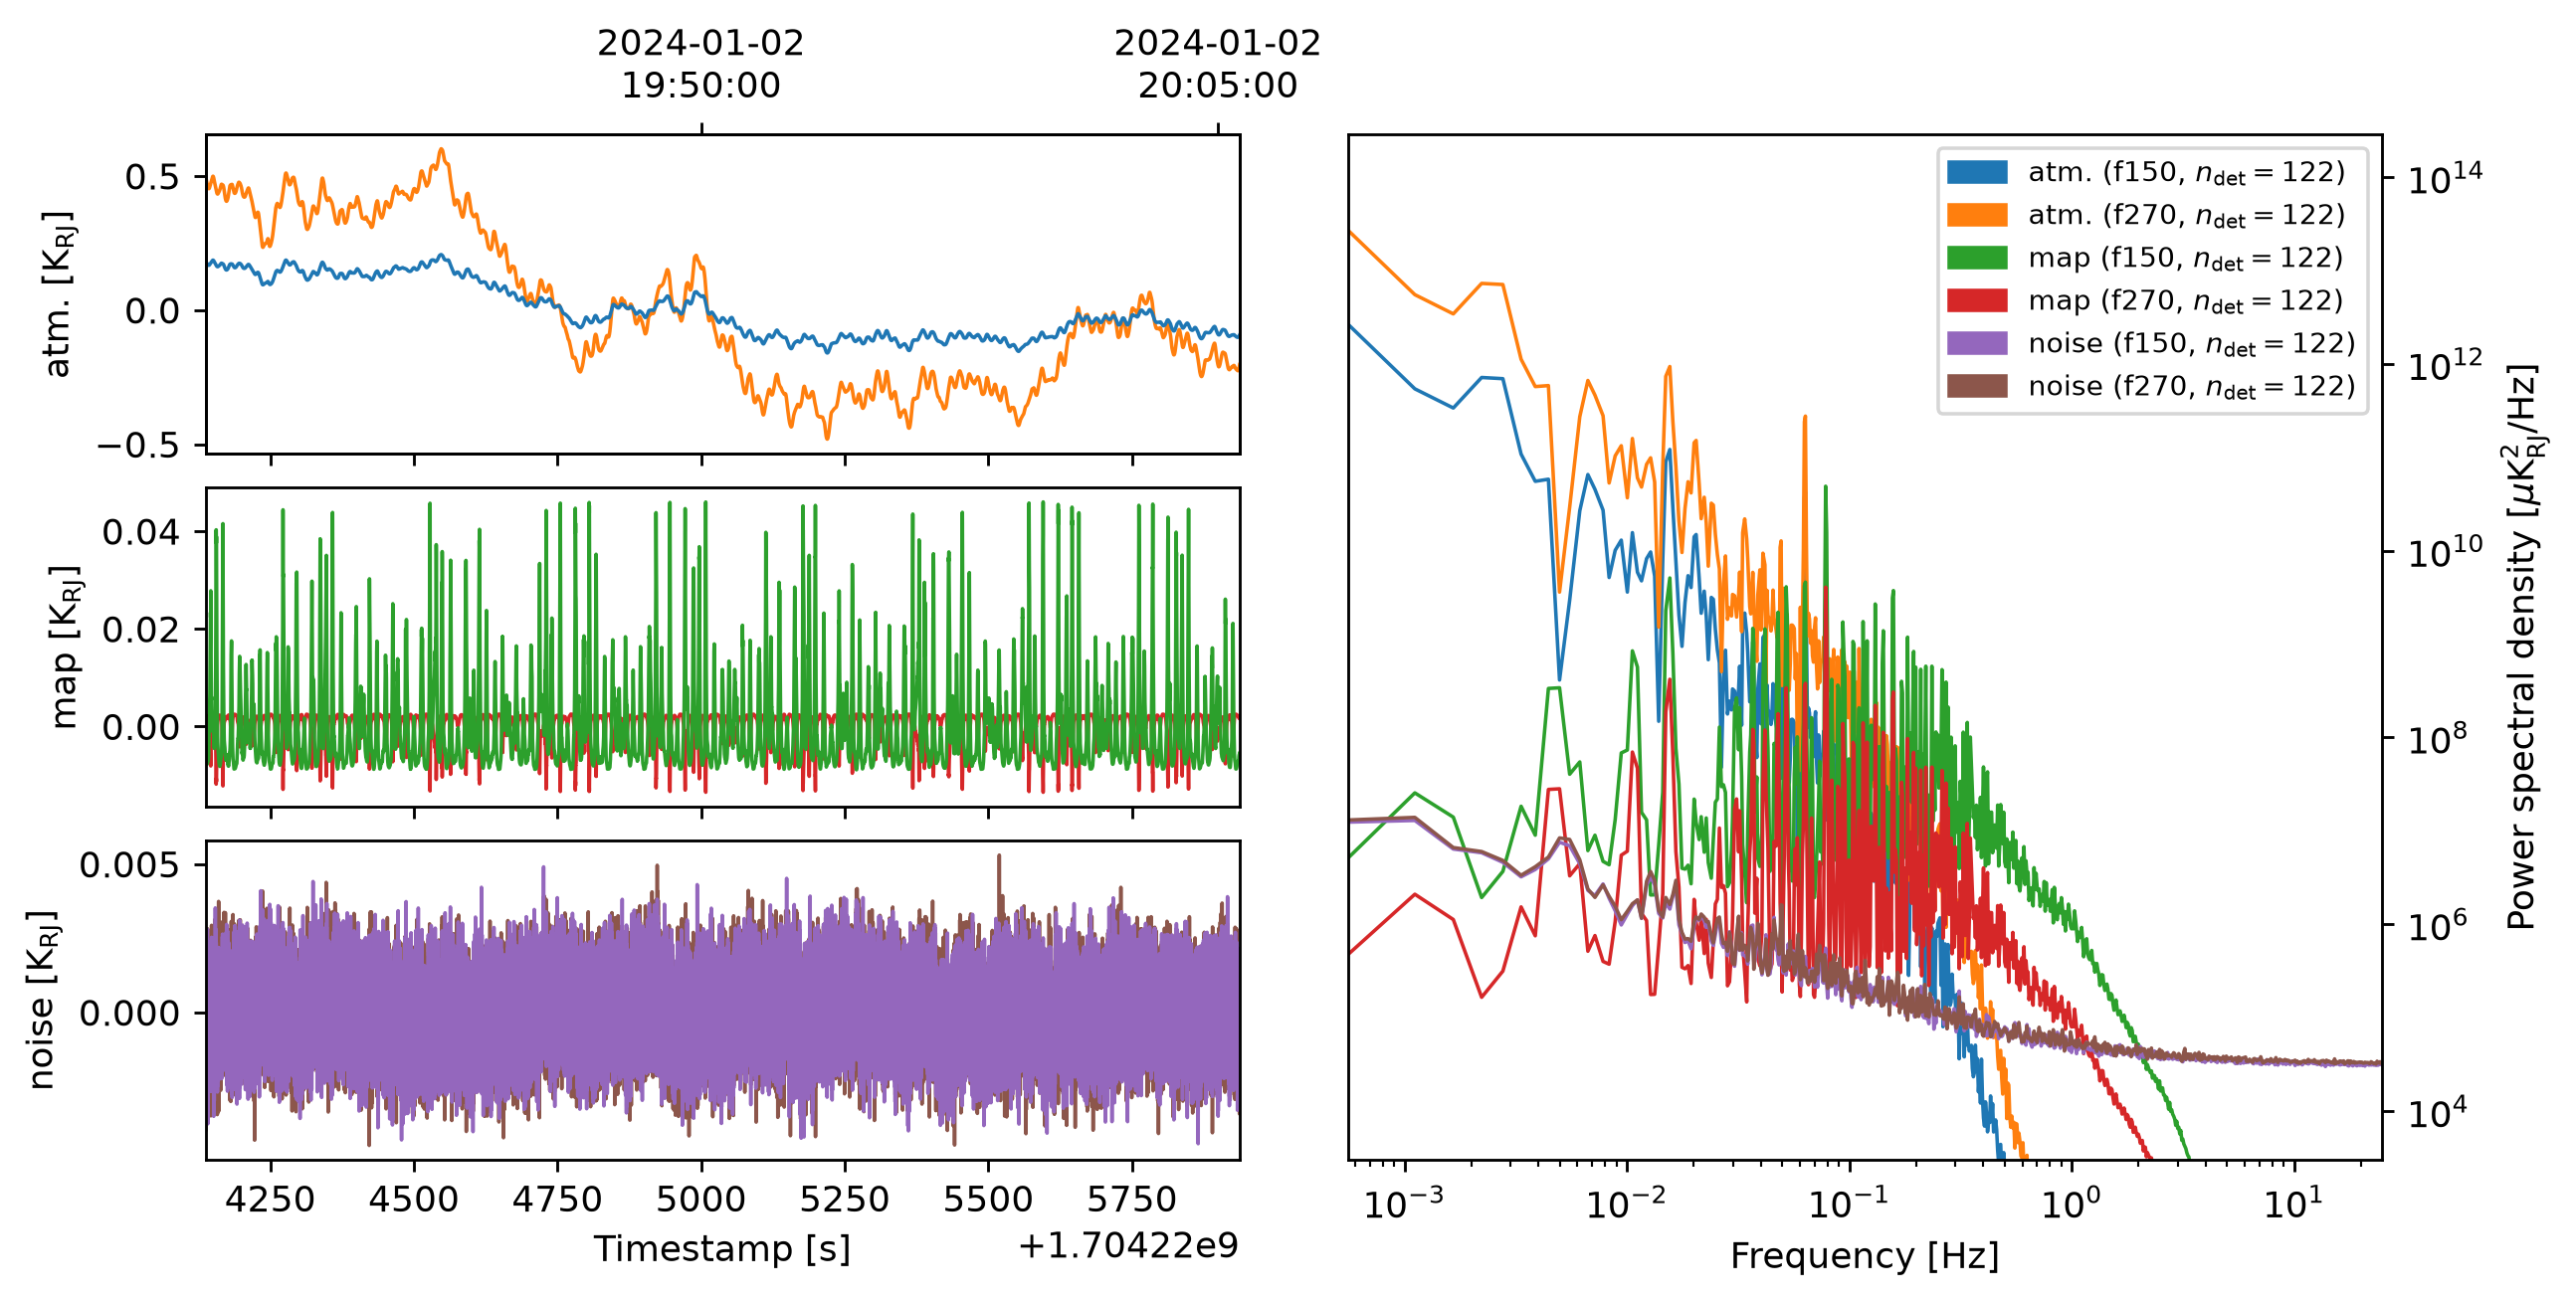

In [4]:
sim = maria.Simulation(
    instrument,
    plans=plans,
    site="llano_de_chajnantor",
    map=input_map,
    atmosphere="2d",
    atmosphere_kwargs={"weather": {"pwv": 0.5}},
    # cmb="generate",
    # cmb_kwargs={"nside": 256},
)

print(sim)

tods = sim.run()
tods[0].plot()

## Mapmaking

Common-mode subtraction (`remove_modes`) and per-detector spline removal (`remove_spline`) suppress large-scale correlated signal. Both operations remove power at long time scales, which maps to large angular scales on the sky, i.e., where $T$ will fall below 1.

> **Note:** `map_postprocessing` is intentionally left empty here. Any map-level post-processing (smoothing, filtering, etc.) applied after binning would itself suppress or modify signal in the output map, and its effect would be absorbed into the measured $T(u)$. To isolate the transfer function of the TOD filtering alone, always set `map_postprocessing={}` when computing transfer functions.

In [5]:
from maria.mapping import MaximumLikelihoodMapper

ml_mapper = MaximumLikelihoodMapper(
    tods=tods,
    units="K_RJ",
    stokes="I",
    resolution=0.5 / 60,
    tod_preprocessing={
        "remove_spline": {"knot_spacing": 60, "remove_el_gradient_order": 1},
    },
    map_postprocessing={},
)


2026-07-06 18:04:34.778 INFO: Inferring center {'ra': '00ʰ00ᵐ0.17ˢ', 'dec': '-23°00’7.80”'} for mapper


2026-07-06 18:04:34.790 INFO: Inferring mapper width 1.236° for mapper from observation patch


2026-07-06 18:04:34.791 INFO: Inferring mapper height 1.236° to match supplied width


Preprocessing TODs:   0%|          | 0/1 [00:00<?, ?it/s]

Preprocessing TODs: 100%|██████████| 1/1 [00:09<00:00,  9.58s/it]

Preprocessing TODs: 100%|██████████| 1/1 [00:09<00:00,  9.58s/it]

Computing pointing matrices:   0%|          | 0/1 [00:00<?, ?it/s]

Computing pointing matrices: 100%|██████████| 1/1 [00:04<00:00,  4.11s/it]

Computing pointing matrices: 100%|██████████| 1/1 [00:04<00:00,  4.11s/it]

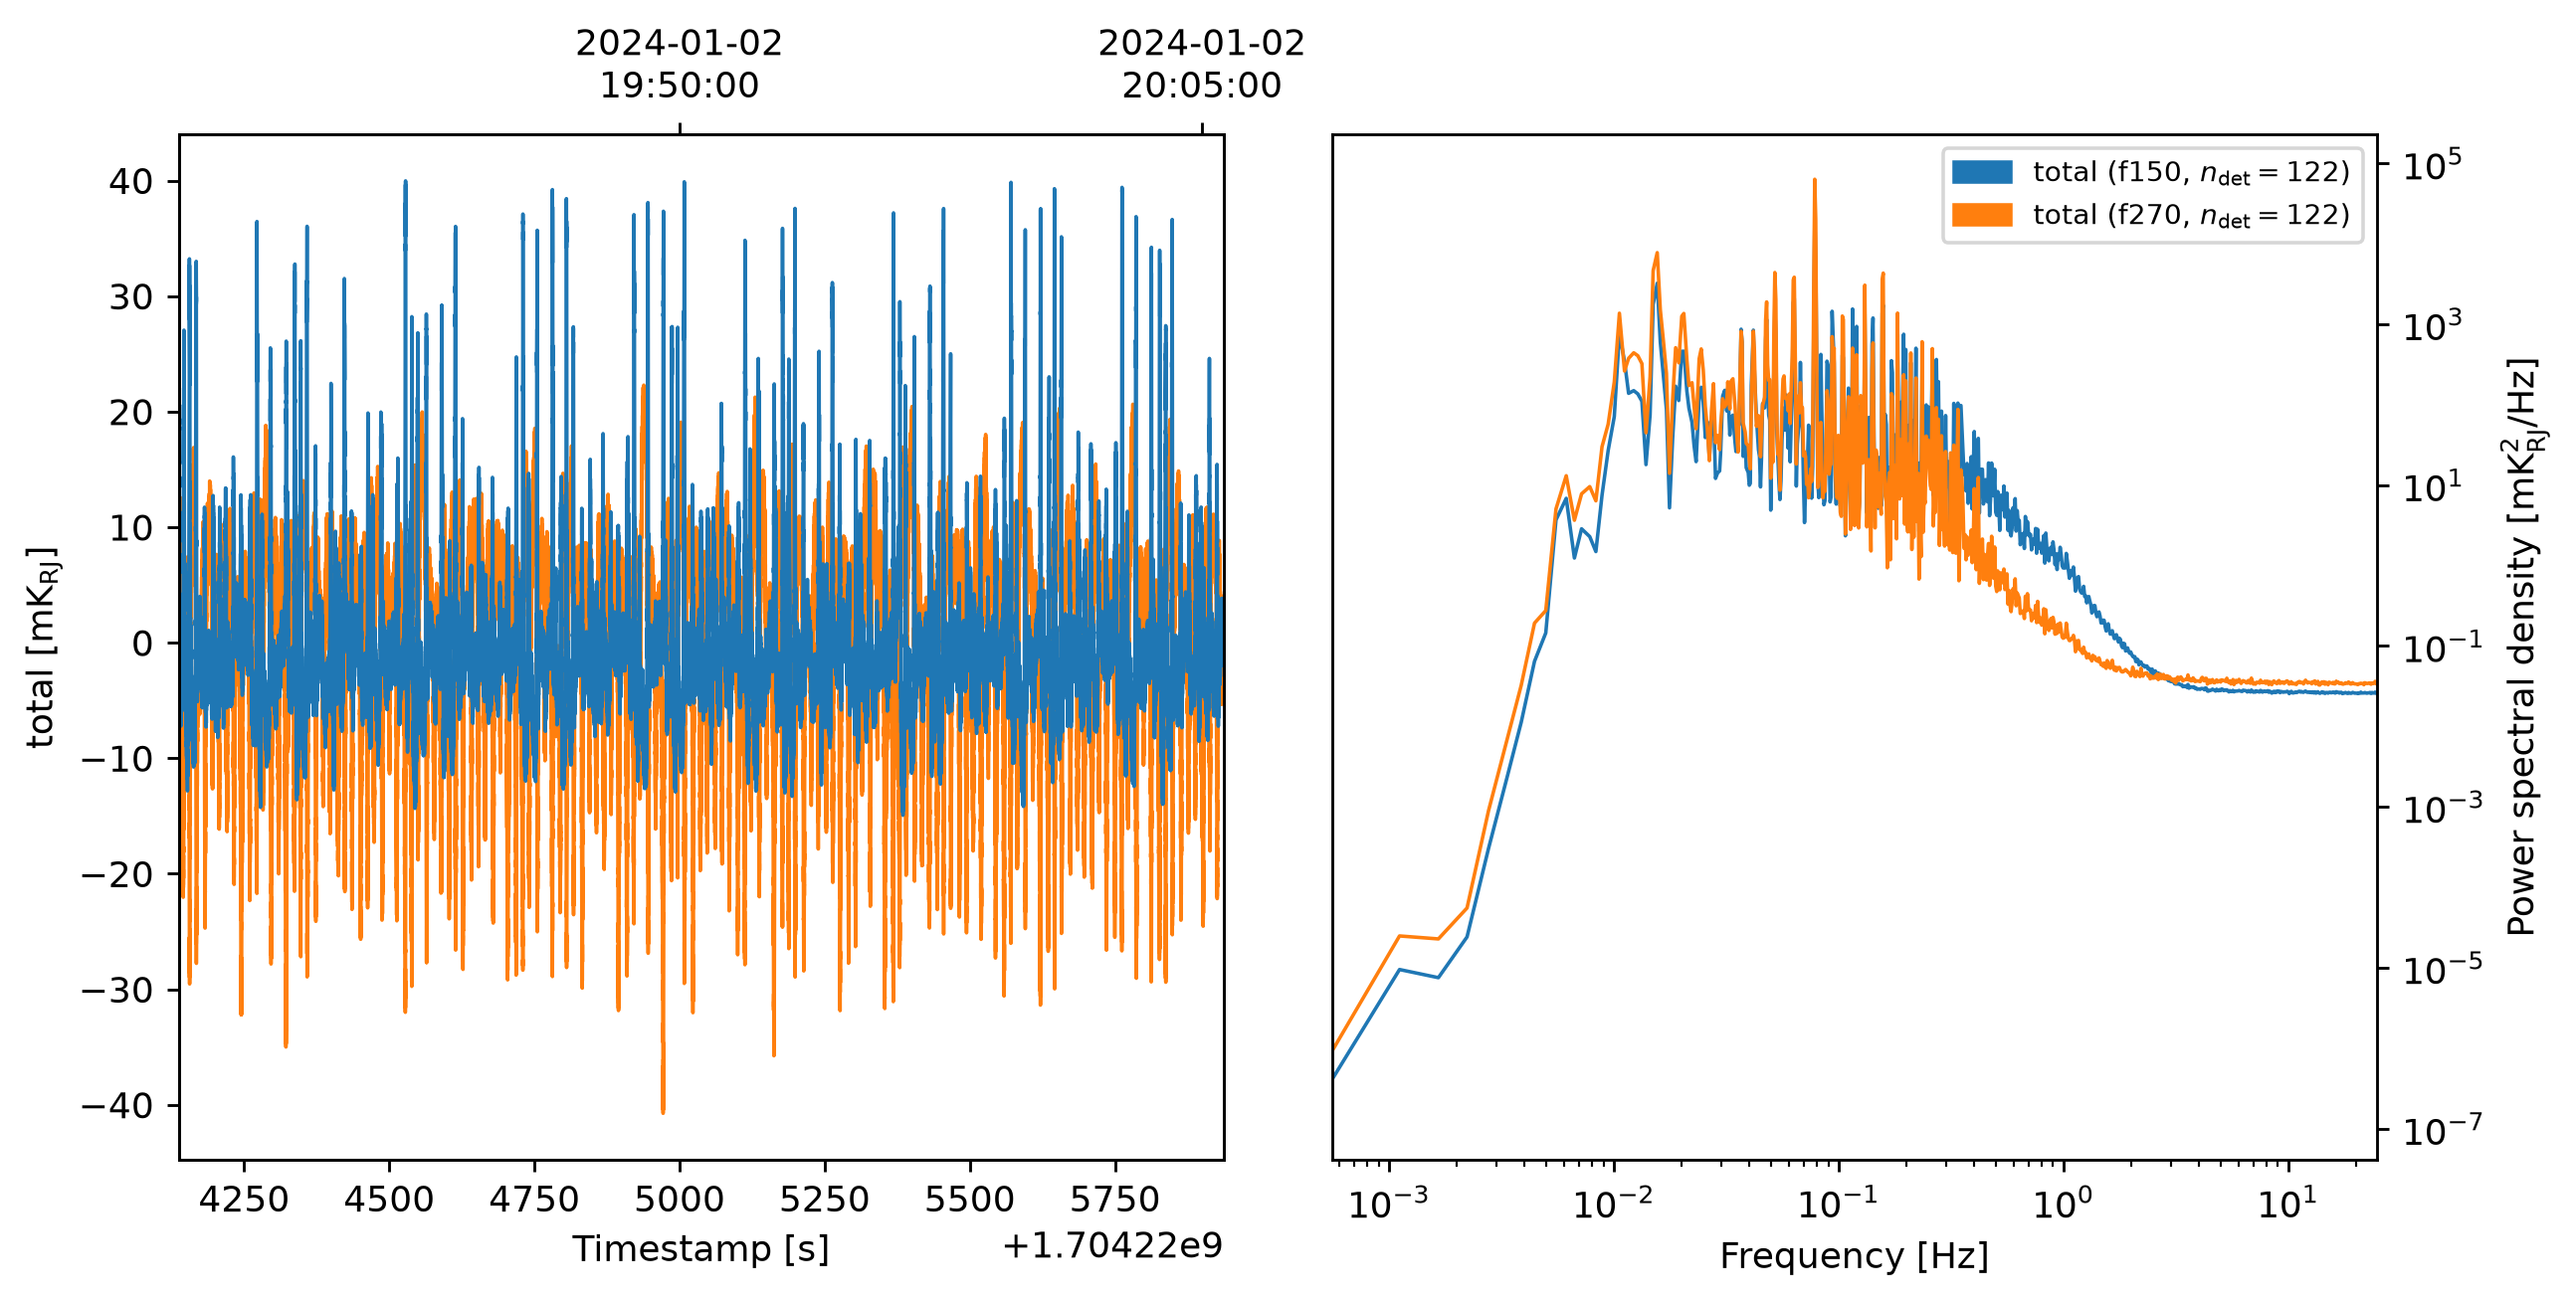

In [6]:
ml_mapper.binner.tods[0].plot()

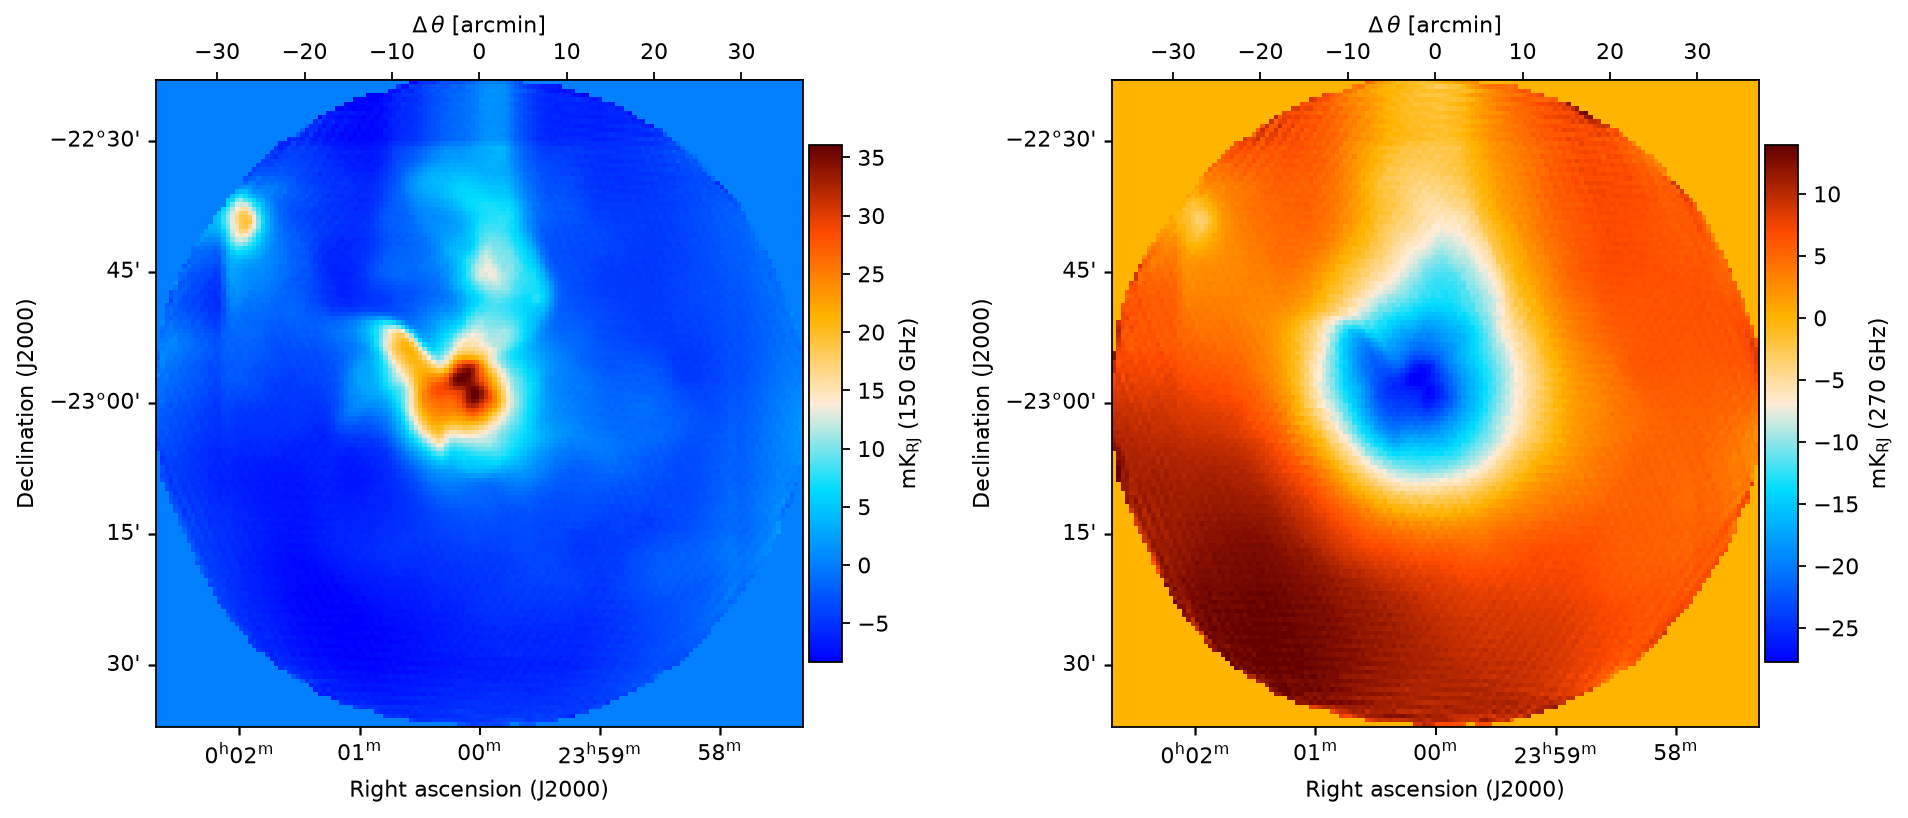

In [7]:
ml_mapper.map.plot(slices="all")

Updating noise model:   0%|          | 0/1 [00:00<?, ?it/s]

Updating noise model:   0%|          | 0/1 [00:00<?, ?it/s, tod=1/1]

Updating noise model: 100%|██████████| 1/1 [00:04<00:00,  4.98s/it, tod=1/1]

Updating noise model: 100%|██████████| 1/1 [00:04<00:00,  4.99s/it, tod=1/1]

Fitting map (epoch 1/2): 0it [00:00, ?it/s]

...

Fitting map (epoch 1/2): 49it [02:44,  3.37s/it, alpha=0.000156]

Fitting map (epoch 1/2): 49it [02:44,  3.37s/it, alpha=0.000154]

Fitting map (epoch 1/2): 50it [02:47,  3.37s/it, alpha=0.000154]

Fitting map (epoch 1/2): 50it [02:47,  3.37s/it, alpha=0.000155]

Fitting map (epoch 1/2): 50it [02:47,  3.36s/it, alpha=0.000155]

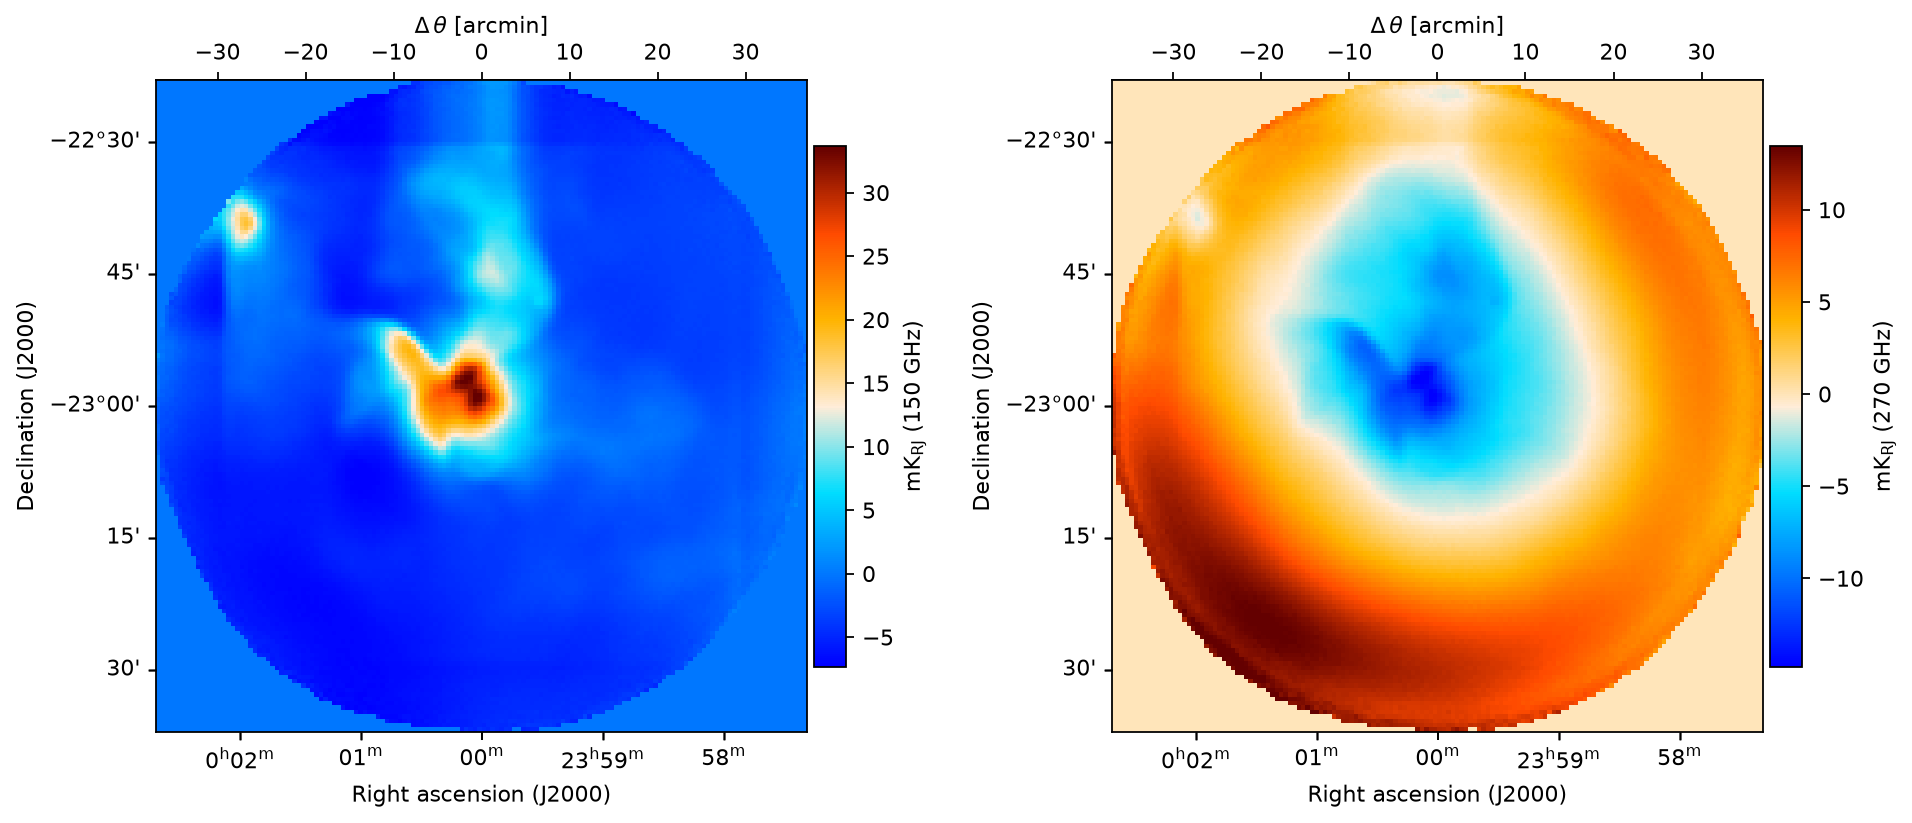

Updating noise model:   0%|          | 0/1 [00:00<?, ?it/s]

Updating noise model:   0%|          | 0/1 [00:00<?, ?it/s, tod=1/1]

Updating noise model: 100%|██████████| 1/1 [00:04<00:00,  4.89s/it, tod=1/1]

Updating noise model: 100%|██████████| 1/1 [00:04<00:00,  4.89s/it, tod=1/1]

Fitting map (epoch 2/2): 0it [00:00, ?it/s]

...

Fitting map (epoch 2/2): 49it [02:44,  3.38s/it, alpha=0.000154]

Fitting map (epoch 2/2): 49it [02:44,  3.38s/it, alpha=0.000138]

Fitting map (epoch 2/2): 50it [02:48,  3.38s/it, alpha=0.000138]

Fitting map (epoch 2/2): 50it [02:48,  3.38s/it, alpha=0.000144]

Fitting map (epoch 2/2): 50it [02:48,  3.36s/it, alpha=0.000144]

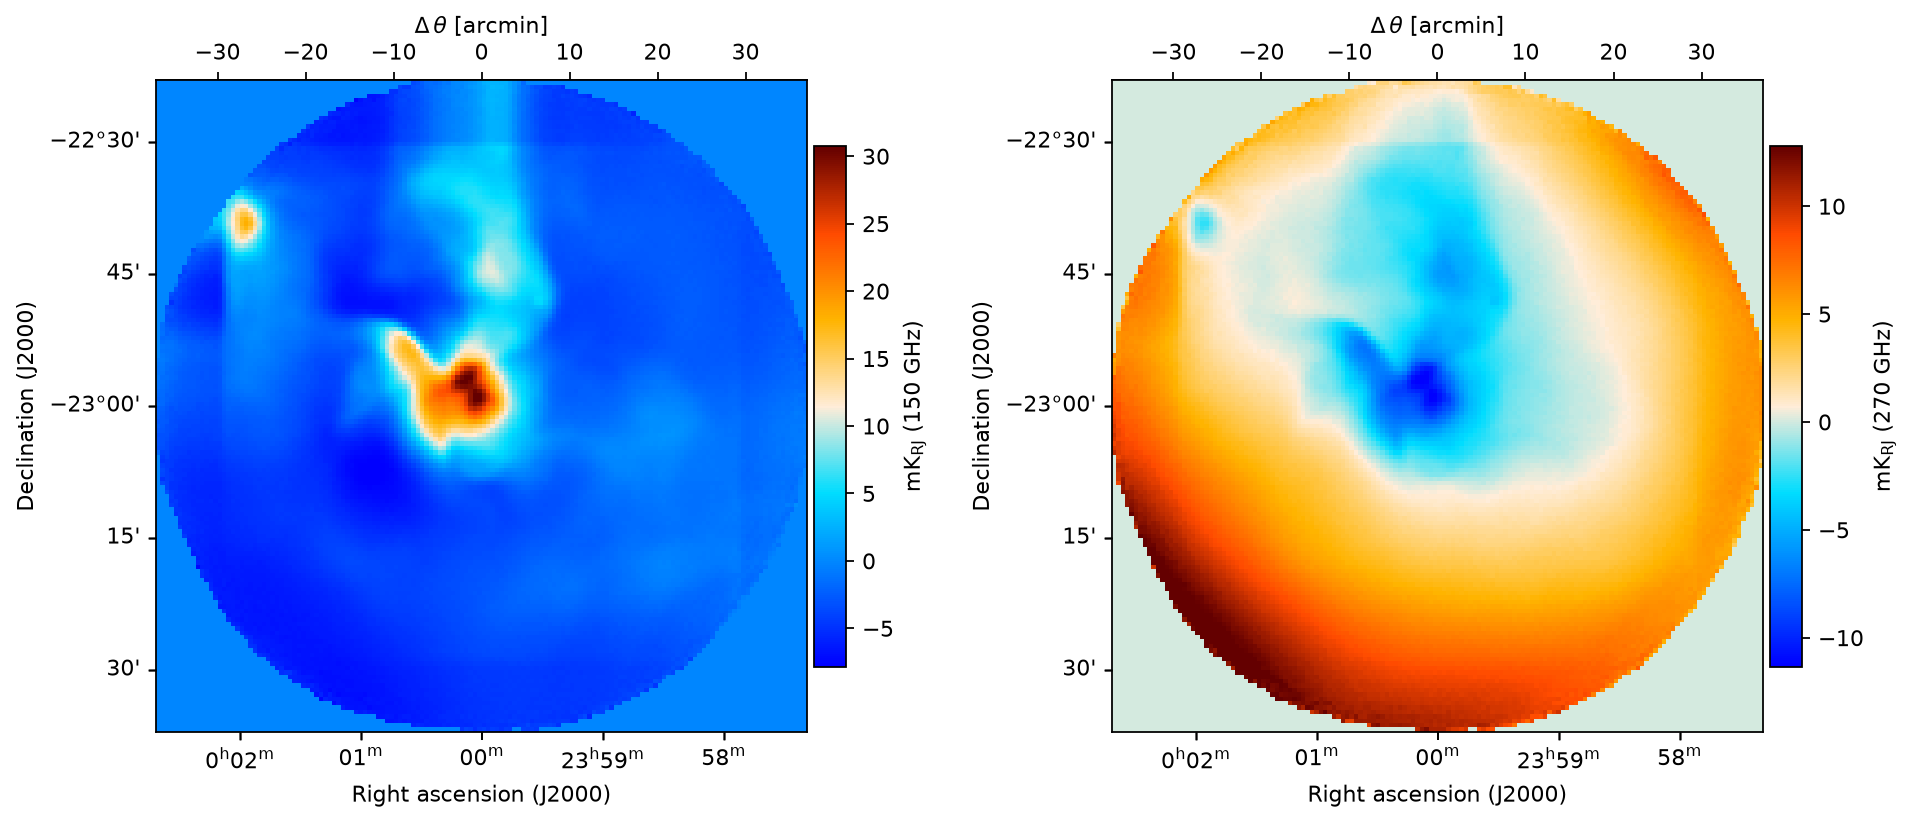

In [8]:
ml_mapper.fit(epochs=2, 
              max_steps_per_epoch=50, 
              plot=True,
              plot_kwargs={"slices": "all"})

output_map = ml_mapper.map

## Transfer function

To compute the transfer function, call `transfer_function()` on the output map. This will return a `TransferFunction` object containing the transfer function $T(u)$ and the corresponding spatial frequencies $u$. The transfer function can be plotted to visualize the scale-dependent signal loss.

In [9]:
tf = output_map.transfer_function(window=True, input_map=input_map)
print(tf)

TransferFunction:
  channels: 2
  nu: [150. 270.] GHz
  bins: 20
  u: [51.7, 3.09e+03] cycles/rad
  T: [0.095, 0.987]


To visualize the transfer function, it is possible to use the built-in `plot()` method. Solid curves show the measured $T(u)$, while dashed curves show the Gaussian beam per channel. The large-scale rolloff reflects the TOD filtering above, while the small-scale rolloff tracks the beam.

<Axes: xlabel='Angular scale [arcmin]', ylabel='Transfer function'>

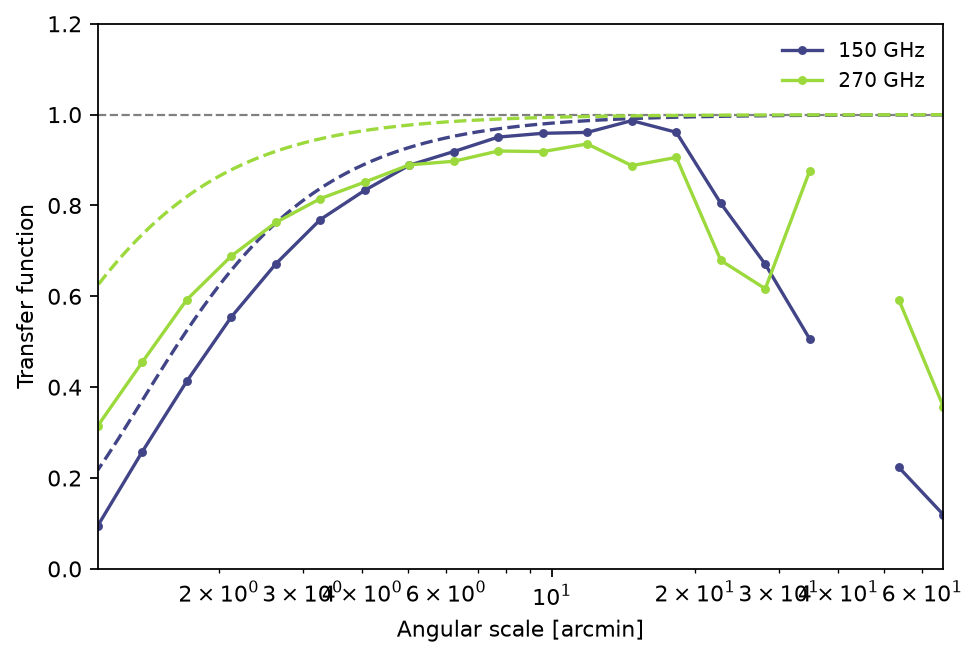

In [10]:
tf.plot(x_unit="arcmin")

Finally, individual channels can be selected with `slices=dict(nu=[...])`, consistent with how `slices` is used in `.plot()`:

<Axes: xlabel='Angular scale [arcmin]', ylabel='Transfer function'>

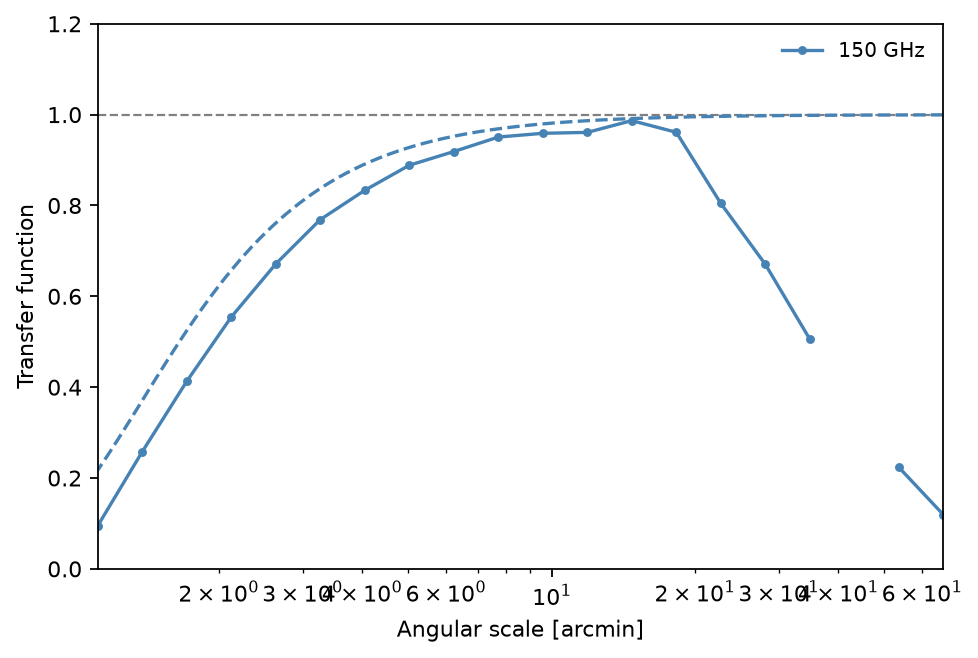

In [11]:
tf.plot(slices=dict(nu=[0]), x_unit="arcmin")

## Apodization window

Before the FFT, `transfer_function()` multiplies both maps by a 2D apodization window to suppress spectral leakage from sharp map edges. The `window` argument controls which window is applied:

| Value | Shape | When to use |
|-------|-------|-------------|
| `"hann"` (default) | Full cosine taper to zero at both edges | Strongest leakage suppression; best when the field is much larger than the scales of interest, since it discards edge signal |
| `"tukey"` | Cosine taper on outer `taper` fraction, central region = 1 | Mild apodization that preserves most of the map signal and substantially reduces edge leakage |
| `np.ndarray` of shape `(ny, nx)` | User-supplied 2D window | Full control — e.g. to mask point sources or weight by the hit-count map |
| `False` / `None` | No window (rectangular) | Maximum large-scale sensitivity; avoid unless the map has periodic or artificially zero-padded boundaries |

The `taper` parameter (default 0.1) sets the fraction of each axis tapered by the Tukey roll-off. Increasing it toward 1 makes the Tukey window approach a Hann window.

> **Tip:** for typical BinMapper output maps, where valid signal extends close to the boundary, `"tukey"` with a small `taper` is preferred over `"hann"`. The full Hann taper downweights map edges heavily, effectively shrinking the usable field and worsening large-scale mode recovery.

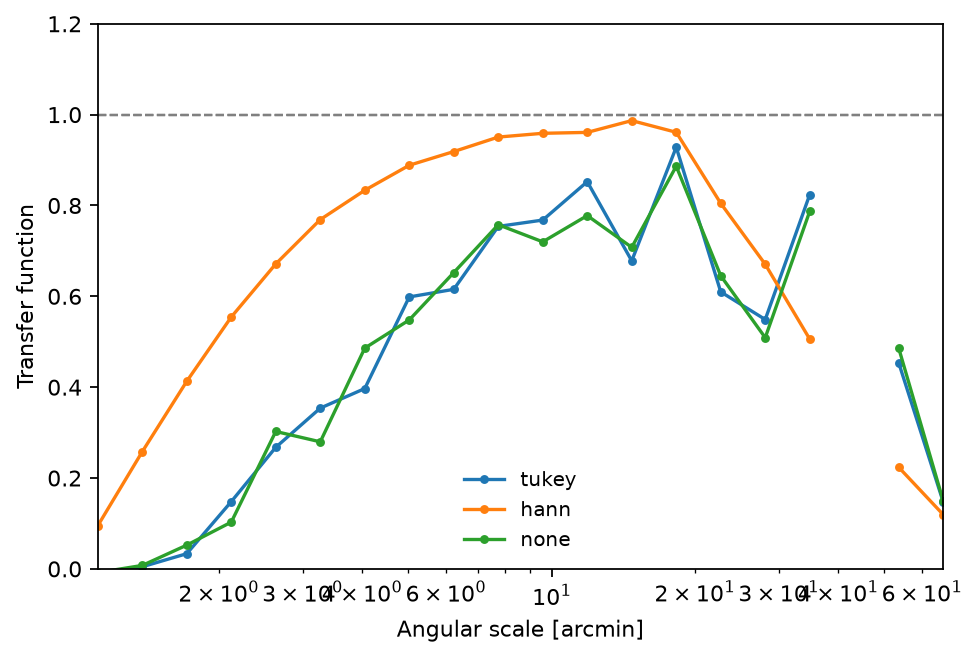

In [12]:
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

windows = [
    ("tukey", dict(window="tukey", taper=0.1)),
    ("hann", dict(window="hann")),
    ("none", dict(window=False)),
]

for i, (label, kwargs) in enumerate(windows):
    tf_w = output_map.transfer_function(slices=dict(nu=[0]), input_map=input_map, **kwargs)
    tf_w.plot(ax=ax, x_unit="arcmin", add_beam=False)
    ax.lines[-1].set_label(label)
    ax.lines[-1].set_color(f"C{i}")

ax.legend(frameon=False, fontsize=9)
plt.show()